In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Kolon isimlerini CMAPSS standardına göre belirliyoruz
col_names = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]

# 2. Eğitim verisini (FD004) yüklüyoruz
train_df = pd.read_csv('train_FD004.txt', sep='\s+', header=None, names=col_names)

# 3. Rejim Tespiti İçin Ayar (Setting) Kolonlarını Seçiyoruz
settings_data = train_df[['setting_1', 'setting_2', 'setting_3']]

# 4. K-Means algoritması ile 6 farklı uçuş koşulunu (regime) kümeliyoruz
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
train_df['regime'] = kmeans.fit_predict(settings_data)

# Sonuçları ekrana basıyoruz
print("✅ FD004 Eğitim Verisi Başarıyla Yüklendi!")
print(f"Toplam Satır ve Sütun: {train_df.shape}")
print("-" * 40)
print("Tespit Edilen 6 Farklı Uçuş Rejimi ve Satır Sayıları:")
print(train_df['regime'].value_counts().sort_index())

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_35230/3938525231.py:10: SyntaxWarning: invalid escape sequence '\s'
  train_df = pd.read_csv('train_FD004.txt', sep='\s+', header=None, names=col_names)


✅ FD004 Eğitim Verisi Başarıyla Yüklendi!
Toplam Satır ve Sütun: (61249, 27)
----------------------------------------
Tespit Edilen 6 Farklı Uçuş Rejimi ve Satır Sayıları:
regime
0    15395
1     9224
2     9139
3     9091
4     9238
5     9162
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
from IPython.display import display

# 1. FAYDALI SENSÖRLERİ SEÇME
# Literatürde FD004 için en kritik 14 sensör seçilir.
# Varyansı olmayan (sabit kalan) sensörler yapay zekayı yanıltır, bu yüzden dışarıda bırakıyoruz.
useful_sensors = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

# Orijinal veriyi bozmamak için kopyası üzerinden çalışıyoruz
train_df_norm = train_df.copy()

# 2. REJİM NORMALİZASYONU (Z-Score)
# Sensör dalgalanmalarını irtifa değişiminden arındırıp, sadece "hasar" sinyaline odaklıyoruz.
for regime in train_df_norm['regime'].unique():
    regime_mask = train_df_norm['regime'] == regime
    scaler = StandardScaler()
    # Sensörleri SADECE o anki uçuş rejimine göre hizala
    train_df_norm.loc[regime_mask, useful_sensors] = scaler.fit_transform(train_df_norm.loc[regime_mask, useful_sensors])

# 3. ÜSTEL HAREKETLİ ORTALAMA (EWMA) FİLTRESİ
# Sinyaldeki mikro titreşimleri (gürültüleri) yumuşatıyoruz.
alpha = 0.1 # Sinyal yumuşatma katsayısı
for unit in train_df_norm['unit_nr'].unique():
    unit_mask = train_df_norm['unit_nr'] == unit
    train_df_norm.loc[unit_mask, useful_sensors] = train_df_norm.loc[unit_mask, useful_sensors].ewm(alpha=alpha, adjust=False).mean()

# 4. SON TEMİZLİK
# Sadece motor numarası, uçuş döngüsü ve temizlenmiş 14 sensörü bırakıyoruz.
final_columns = ['unit_nr', 'time_cycles'] + useful_sensors
train_df_final = train_df_norm[final_columns]

print("✅ Adım 2 Kusursuz Tamamlandı: Rejim Normalizasyonu ve EWMA Filtresi uygulandı!")
print(f"Elde edilen temizlenmiş veri seti boyutu: {train_df_final.shape}")
print("\nİşte yapay zekaya yedireceğimiz pürüzsüzleştirilmiş verinin ilk 5 satırı:")
display(train_df_final.head())

/tmp/ipykernel_35230/1124918174.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.32737159 -0.92936463 -1.53135767 ...  2.08060055  1.47860752
  1.47860752]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df_norm.loc[regime_mask, useful_sensors] = scaler.fit_transform(train_df_norm.loc[regime_mask, useful_sensors])


✅ Adım 2 Kusursuz Tamamlandı: Rejim Normalizasyonu ve EWMA Filtresi uygulandı!
Elde edilen temizlenmiş veri seti boyutu: (61249, 16)

İşte yapay zekaya yedireceğimiz pürüzsüzleştirilmiş verinin ilk 5 satırı:


,unit_nr,time_cycles,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
0,1,1,0.435226,-1.384552,-1.281826,-1.514067,-0.607851,-0.876658,-1.207045,-1.092784,-0.385998,-0.945381,0.022482,-0.327372,-0.024003,-0.079914
1,1,2,0.144465,-1.334895,-1.289360,-1.509428,-0.713122,-0.876844,-1.227937,-1.131083,-0.538127,-0.988188,0.021440,-0.522379,-0.115698,-0.135372
2,1,3,0.016325,-1.344560,-1.242926,-1.430728,-0.677473,-0.901812,-1.236273,-1.143994,-0.530669,-1.032790,0.114661,-0.563077,-0.224535,-0.053665
3,1,4,-0.152842,-1.381761,-1.190269,-1.379206,-0.662137,-0.893738,-1.236826,-1.136781,-0.504570,-1.016785,0.110155,-0.659905,-0.271914,0.014682
4,1,5,-0.303041,-1.337138,-1.247565,-1.332130,-0.687008,-0.948428,-1.199275,-1.103180,-0.557280,-1.018613,0.060821,-0.721119,-0.463314,0.128599


In [ ]:
# 1. Her motorun (unit_nr) ulaştığı maksimum uçuş döngüsünü (max_cycle) buluyoruz
# (CMAPSS verisinde her motorun son satırı, o motorun bozulduğu anı temsil eder)
rul_df = train_df_final.groupby('unit_nr')['time_cycles'].max().reset_index()
rul_df.columns = ['unit_nr', 'max_cycle']

# 2. Ana veri setimizle bu maksimum değerleri birleştiriyoruz
train_df_final = train_df_final.merge(rul_df, on=['unit_nr'], how='left')

# 3. Kalan Ömrü (RUL) Hesaplama: (Maksimum Döngü - O anki Döngü)
train_df_final['RUL'] = train_df_final['max_cycle'] - train_df_final['time_cycles']

# 4. Kırpılmış (Piece-wise Linear) RUL Uygulaması
# Maksimum RUL limitini 125 olarak ayarlıyoruz
RUL_MAX = 125
train_df_final['RUL'] = train_df_final['RUL'].apply(lambda x: x if x <= RUL_MAX else RUL_MAX)

# 5. Artık işimiz biten 'max_cycle' kolonunu siliyoruz
train_df_final.drop('max_cycle', axis=1, inplace=True)

print("✅ Adım 3 Kusursuz Tamamlandı: Kalan Ömür (RUL) etiketleri hesaplandı ve kırpıldı!")
print("\nMotor 1'in son 5 uçuşuna bakalım (RUL değerinin 0'a doğru nasıl geriye saydığını gör):")
display(train_df_final[train_df_final['unit_nr'] == 1].tail())

✅ Adım 3 Kusursuz Tamamlandı: Kalan Ömür (RUL) etiketleri hesaplandı ve kırpıldı!

Motor 1'in son 5 uçuşuna bakalım (RUL değerinin 0'a doğru nasıl geriye saydığını gör):


,unit_nr,time_cycles,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
316,1,317,0.944007,1.339193,1.250758,2.743214,1.999293,2.096377,1.430786,2.691702,1.873254,2.086588,-2.310728,1.484134,1.567878,1.992602,4
317,1,318,1.015798,1.347633,1.306656,2.816217,2.124815,2.126893,1.511730,2.786554,2.007034,2.145985,-2.331332,1.627417,1.480487,2.019533,3
318,1,319,1.028199,1.401885,1.279128,2.883180,2.226744,2.187755,1.656421,2.871922,2.165103,2.186365,-2.367797,1.695743,1.453875,2.018125,2
319,1,320,0.908317,1.463323,1.338347,2.998165,2.344695,2.260132,1.727064,2.985816,2.298303,2.242029,-2.421441,1.715116,1.518843,2.105324,1
320,1,321,0.867469,1.560273,1.454082,3.097228,2.321589,2.341225,1.735999,3.102156,2.270264,2.302146,-2.455984,1.811864,1.524710,2.015839,0


In [ ]:
import numpy as np

# 1. Zaman Penceresi (Sequence Length) Belirleme
sequence_length = 30 # LSTM her tahminde motorun son 30 uçuşuna geriye dönük bakacak

# 2. 3 Boyutlu Matris Üretici Fonksiyon (Sliding Window)
def gen_sequence(id_df, seq_length, seq_cols):
    data_matrix = id_df[seq_cols].values
    num_elements = data_matrix.shape[0]
    # Her bir pencere için veriyi kaydırarak (sliding) kesiyoruz
    for start, stop in zip(range(0, num_elements - seq_length), range(seq_length, num_elements)):
        yield data_matrix[start:stop, :]

# 3. Eğitim Sensör Verilerini (X) 3 Boyutlu Hale Getirme
sensor_cols = useful_sensors # Bir önceki adımdaki 14 faydalı sensör
seq_gen = (list(gen_sequence(train_df_final[train_df_final['unit_nr'] == id], sequence_length, sensor_cols))
           for id in train_df_final['unit_nr'].unique())

# Üretilen dizileri tek bir devasa Numpy dizisinde birleştiriyoruz
X_train = np.concatenate(list(seq_gen)).astype(np.float32)

# 4. Etiketleri (y) Hazırlama
def gen_labels(id_df, seq_length, label):
    data_matrix = id_df[label].values
    num_elements = data_matrix.shape[0]
    # Etiket, o 30 günlük pencerenin en sonundaki RUL değeridir
    return data_matrix[seq_length:num_elements, :]

label_gen = [gen_labels(train_df_final[train_df_final['unit_nr'] == id], sequence_length, ['RUL'])
             for id in train_df_final['unit_nr'].unique()]

y_train = np.concatenate(label_gen).astype(np.float32)

print("✅ Adım 4 Kusursuz Tamamlandı: LSTM için 3 Boyutlu Zaman Pencereleri (Tensors) oluşturuldu!")
print(f"Eğitim Verisi (X_train) Boyutu: {X_train.shape}")
print(f"Hedef Verisi (y_train) Boyutu: {y_train.shape}")

✅ Adım 4 Kusursuz Tamamlandı: LSTM için 3 Boyutlu Zaman Pencereleri (Tensors) oluşturuldu!
Eğitim Verisi (X_train) Boyutu: (53779, 30, 14)
Hedef Verisi (y_train) Boyutu: (53779, 1)


🧠 LSTM Yapay Zeka Mimarisi Başarıyla Kuruldu!
Eğitim (Antrenman) süreci başlıyor... Bu işlem sunucu hızına göre birkaç dakika sürebilir.

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


242/243 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 8067.5600 - mae: 80.2390

243/243 ━━━━━━━━━━━━━━━━━━━━ 23s 86ms/step - loss: 7311.1890 - mae: 75.7372 - val_loss: 6266.5669 - val_mae: 69.5518
Epoch 2/100
242/243 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 5925.8358 - mae: 67.5203

243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - loss: 5565.1870 - mae: 65.2415 - val_loss: 4846.0771 - val_mae: 60.3831
Epoch 3/100
242/243 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 4593.1780 - mae: 58.4319

...

243/243 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - loss: 396.4048 - mae: 16.3072 - val_loss: 298.3779 - val_mae: 14.9207
Epoch 13/100
242/243 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 346.1572 - mae: 15.0639

243/243 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - loss: 330.9557 - mae: 14.6761 - val_loss: 247.0579 - val_mae: 13.3519
Epoch 14/100
242/243 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 293.0931 - mae: 13.5409

243/243 ━━━━━━━━━━━━━━━━━━━━ 40s 83ms/step - loss: 281.7820 - mae: 13.2044 - val_loss: 198.3709 - val_mae: 11.8698
Epoch 15/100
242/243 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 257.8959 - mae: 12.4187

243/243 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - loss: 249.8524 - mae: 12.1587 - val_loss: 170.3079 - val_mae: 10.8114
Epoch 16/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - loss: 226.9681 - mae: 11.3186 - val_loss: 188.7669 - val_mae: 10.7755
Epoch 17/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 40s 83ms/step - loss: 213.9798 - mae: 10.7693 - val_loss: 204.4252 - val_mae: 10.8138
Epoch 18/100
242/243 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 220.7668 - mae: 10.8284

243/243 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - loss: 209.1017 - mae: 10.5249 - val_loss: 129.7386 - val_mae: 8.6411
Epoch 19/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - loss: 196.8058 - mae: 10.1252 - val_loss: 173.2556 - val_mae: 9.6256
Epoch 20/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - loss: 188.1695 - mae: 9.8890 - val_loss: 158.8446 - val_mae: 9.0219
Epoch 21/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - loss: 202.5230 - mae: 10.2528 - val_loss: 200.2650 - val_mae: 9.5621
Epoch 22/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - loss: 203.2609 - mae: 10.1862 - val_loss: 150.3342 - val_mae: 8.5053
Epoch 23/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - loss: 184.7888 - mae: 9.7476 - val_loss: 156.6026 - val_mae: 8.6025
Epoch 24/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - loss: 180.7372 - mae: 9.6384 - val_loss: 152.3491 - val_mae: 8.5967
Epoch 25/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - loss: 173.7105 - mae: 9.4789 - val_loss: 163.4873 - val_mae: 8.5926
E

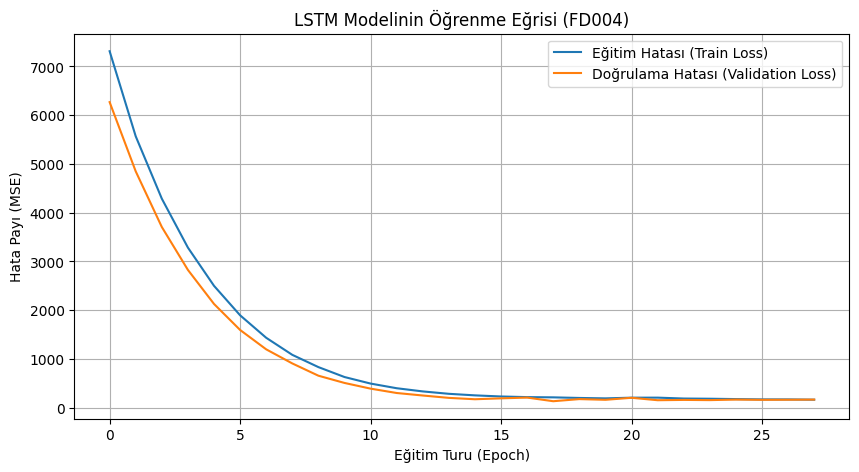

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# 1. Modelin Girdi Boyutlarını Belirleme
nb_features = X_train.shape[2] # 14 Sensör
nb_out = y_train.shape[1]      # 1 Hedef (RUL)

# 2. Çift Katmanlı Derin LSTM Mimarisi
model = Sequential()

# İlk LSTM Katmanı (Gelecek katmana veriyi dizi olarak iletir: return_sequences=True)
model.add(LSTM(
         input_shape=(sequence_length, nb_features),
         units=100,
         return_sequences=True))
model.add(Dropout(0.2)) # Modelin ezberlemesini önlemek için nöronların %20'sini rastgele uyutuyoruz

# İkinci LSTM Katmanı (Sonuçları toparlar)
model.add(LSTM(
          units=50,
          return_sequences=False))
model.add(Dropout(0.2))

# Çıkış Katmanı (Kalan Ömrü tahmin eden tek bir nöron)
model.add(Dense(units=nb_out, activation='linear'))

# 3. Modeli Derleme (Compile)
# Hata fonksiyonu olarak Mean Squared Error (Ortalama Karesel Hata) kullanıyoruz
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

# 4. Akıllı Eğitim Kontrolcüleri (Callbacks)
# Eğer model 10 tur boyunca (patience=10) gelişmezse eğitimi durdur ve en iyi ağırlıkları geri yükle
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# Sadece en düşük hataya sahip modeli 'cmapss_fd004_lstm_v1.h5' adıyla diske kaydet
checkpoint = ModelCheckpoint('cmapss_fd004_lstm_v1.h5', monitor='val_loss', save_best_only=True)

print("🧠 LSTM Yapay Zeka Mimarisi Başarıyla Kuruldu!")
print("Eğitim (Antrenman) süreci başlıyor... Bu işlem sunucu hızına göre birkaç dakika sürebilir.\n")

# 5. Eğitimi Başlat (Fit)
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=200,
                    validation_split=0.1, # Verinin %10'unu kendini test etmek için ayırır
                    callbacks=[early_stop, checkpoint],
                    verbose=1)

print("\n✅ Eğitim Kusursuz Bir Şekilde Tamamlandı!")

# 6. Öğrenme Eğrisini (Loss Curve) Çizdirme
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Eğitim Hatası (Train Loss)')
plt.plot(history.history['val_loss'], label='Doğrulama Hatası (Validation Loss)')
plt.title('LSTM Modelinin Öğrenme Eğrisi (FD004)')
plt.ylabel('Hata Payı (MSE)')
plt.xlabel('Eğitim Turu (Epoch)')
plt.legend()
plt.grid(True)
plt.show()